This code plots proper motion (in galactic coordinates) from the output file from running Synthpop using population and distance cut to separate disk and bulge stars

This version is updated to use catalogs from most recent version of SynthPop which removed a bug

Old version of this code is fucking awful because I suck at coding, so let me stop copy-pasting everything 8 times

archive data is from https://archive.stsci.edu/prepds/wfc3bulge/

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.special import erf
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS

from astropy.coordinates import SkyCoord
import astropy.units as u

# Set variables and settings

In [2]:
# Arguments
window_idx = 2
norm = False
sep_idx = 1
model = 0
fit = 1 # Tell the code whether you want to fit the archive data or not (debugging)
branch = 1 # Branch of SynthPop being used (dev or v2); USE DEV FOR THE SYNTHPOP PAPER

In [3]:
# Settings
bulge_pop = 0				# Population 0 is for the bulge
disk_pops = [2, 3, 4, 5, 6, 7, 8, 9]	# Populations 2-9 are for the disk
magcut = 18
arch_magcut = 18
bright_magcut = 14 # Get rid of the bright SynthPop stars
pixel_scale_arcsec = 0.03 # From readme documentation in the archive [arcsec/px]
pixel_scale = 1000 * pixel_scale_arcsec # [mas/px]
arch_bin_width = 0.8
galcenter = 8. # Distance to galactic center; used to separate near and far disk [kpc]
fontsize = 12
#spfilt1 = "Bessell_I"
#spfilt2 = "Bessell_V"
spfilt1 = "WFC3_UVIS_F814W"
spfilt2 = "WFC3_UVIS_F555W"

# Indices of the free parameters of the gaussian fit
gauss_N_idx = 0
gauss_mean_idx = 1
gauss_sigma_idx = 2

# CDF fit range around median
cdf_median_range = [0.3, 0.7]

######## Options ########
#solid_angle = 0.0003
#solid_angle = 0.002025
#solid_angle = 0.001
#solid_angle = 0.01
solid_angle = 0.00318 # Matched field size with Hubble field
#########################

# Dictionaries

In [4]:
## Dict with values of: bin_width
#bin_width = 0.2
cut_dict = {
	0: 0.6,
	1: 1.0
}
bin_width = float(cut_dict[sep_idx])

# Output file (Synthpop catalog) to use
if model == 0:
    if branch == 0:
        catalog_dict = {
            0: ["Huston2025_l1.060_b-3.810_baade.csv", "hlsp_wfc3bulge_hst_wfc3_baade_multi_v2.0_cat.fits"],
            1: ["Huston2025_l353.250_b-4.720_ogle29.csv", "hlsp_wfc3bulge_hst_wfc3_ogle29_multi_v2.0_cat.fits"],
            2: ["Huston2025_l0.250_b-2.150_stanek.csv", "hlsp_wfc3bulge_hst_wfc3_stanek_multi_v2.0_cat.fits"],
            3: ["Huston2025_l1.260_b-2.650_sweeps.csv", "hlsp_wfc3bulge_hst_wfc3_sweeps_multi_v2.0_cat.fits"]
        }
    elif branch == 1:
        catalog_dict = {
            0: ["Huston2025_l1.060_b-3.810_baade_match_fieldsize_dev.csv", "hlsp_wfc3bulge_hst_wfc3_baade_multi_v2.0_cat.fits"],
            1: ["Huston2025_l353.250_b-4.720_ogle29_match_fieldsize_dev.csv", "hlsp_wfc3bulge_hst_wfc3_ogle29_multi_v2.0_cat.fits"],
            2: ["Huston2025_l0.250_b-2.150_stanek_match_fieldsize_dev.csv", "hlsp_wfc3bulge_hst_wfc3_stanek_multi_v2.0_cat.fits"],
            3: ["Huston2025_l1.260_b-2.650_sweeps_match_fieldsize_dev.csv", "hlsp_wfc3bulge_hst_wfc3_sweeps_multi_v2.0_cat.fits"]
        }
    '''
    catalog_dict = {
        0: ["Huston2025_l1.060_b-3.810_baade.csv", "hlsp_wfc3bulge_hst_wfc3_baade_multi_v2.0_cat.fits"],
        1: ["Huston2025_l353.250_b-4.720_ogle29.csv", "hlsp_wfc3bulge_hst_wfc3_ogle29_multi_v2.0_cat.fits"],
        2: ["Huston2025_l0.250_b-2.150_stanek_debug.csv", "hlsp_wfc3bulge_hst_wfc3_stanek_multi_v2.0_cat.fits"],
        3: ["Huston2025_l1.260_b-2.650_sweeps.csv", "hlsp_wfc3bulge_hst_wfc3_sweeps_multi_v2.0_cat.fits"]
    }'''
else:
    catalog_dict = {
    	0: ["Huston2025_l1.060_b-3.810_baade.csv", "hlsp_wfc3bulge_hst_wfc3_baade_multi_v2.0_cat.fits"],
    	1: ["Huston2025_l353.250_b-4.720_ogle29.csv", "hlsp_wfc3bulge_hst_wfc3_ogle29_multi_v2.0_cat.fits"],
    	2: ["besancon_Robin2003_l0.250_b-2.150_stanek.csv", "hlsp_wfc3bulge_hst_wfc3_stanek_multi_v2.0_cat.fits"],
    	3: ["Huston2025_l1.260_b-2.650_sweeps.csv", "hlsp_wfc3bulge_hst_wfc3_sweeps_multi_v2.0_cat.fits"]
    }
catalog = "kinematics/"+catalog_dict[window_idx][0]
if branch == 0:
    window = catalog.rsplit("_", 1)[-1].replace(".csv", "").capitalize()
#print(catalog.rsplit("_", 1))
elif branch == 1:
    window = catalog.rsplit("_", 4)[1].replace(".csv", "").capitalize()
print(window)

# Dict has values of: baseline [yr] (from readme file in archive data), color cut (from looking at cmd)
#field_info_dict = {
#	0: [2.09, 1.432],
#	1: [2.08, 1.382],
#	2: [2.00, 1.672],
#	3: [6.21, 1.447]
#}
#field_info_dict = {
#	0: [2.09, 0.22],
#	1: [2.08, 0.23],
#	2: [2.00, 0.44],
#	3: [6.21, 0.30]
#}
'''
# Dict has values of: baseline [yr] (from readme file in archive data), SynthPop color cut (from looking at cmd), Hubble color cut
field_info_dict = {
	0: [2.09, 0.15, 0.22],
	1: [2.08, 0.16, 0.25],
	2: [2.00, 0.26, 0.44],
	3: [6.21, 0.15, 0.30]
}
'''
# Dict has values of: baseline [yr] (from readme file in archive data), SynthPop color cut (from looking at cmd), Hubble color cut
# THIS WAS FOR WHEN I USED DIFFERENT COLOR CUTS FOR THE DIFFERENT CATALOGS
#field_info_dict = {
#	0: [2.09, 0.17, 0.22],
#	1: [2.08, 0.16, 0.25],
#	2: [2.00, 0.45, 0.53],
#	3: [6.21, 0.21, 0.30]
#}

# Dict has values of: baseline [yr] (from readme file in archive data), SynthPop color cut (from looking at cmd), Hubble color cut
field_info_dict = {
	0: [2.09, 0.17, 0.17],
	1: [2.08, 0.16, 0.16],
	2: [2.00, 0.45, 0.45],
	3: [6.21, 0.21, 0.21]
}
baseline = float(field_info_dict[window_idx][0])
colorcut = float(field_info_dict[window_idx][1])
arch_colorcut = float(field_info_dict[window_idx][2])

Stanek


# Functions

In [5]:
################ Functions ################
#def normalize(hist_vals):
#	return hist_vals / np.sum(hist_vals)
	
def gaussian(x, N, mean, sigma):
	amplitude = N/np.sqrt(2*np.pi*sigma**2)
	return amplitude * np.exp(-((x - mean) / sigma) ** 2 / 2)

def gaussian_cdf(x, mu, sigma):
    return 0.5 * (1 + erf((x - mu) / (np.sqrt(2) * sigma)))

# Find bin centers
#def find_centers(edg):
#	return (edg[:-1] + edg[1:]) / 2
	
# Convert counts to plotLF2023.py
def convert_units(hist):
	solid_angle_arcmin = float(solid_angle) * 3600		# Convert solid angle from deg^2 to arcmin^2

	# Calculate the y-axis to match the y-axis in Figure 3 of Mroz
	return (hist / solid_angle_arcmin / bin_width)

def gauss_fit(mu, edg, archive, norm_factor = 1.):
    '''
    norm_factor
        optional normalization factor, if you want to normalize hubble/synthpop histograms to look more comparable
    '''
    # Calculate histogram information
    if norm == "True":
        hist, edges = np.histogram(mu, bins=edg, density=True)
    else:
        hist, edges = np.histogram(mu, bins=edg)

    centers = (edges[:-1] + edges[1:]) / 2
    #print(f"hist: {hist}")
    #print(f"length of hist: {len(hist)}")
    #print(f"length of edges: {len(edges)}")
    #print(f"archive flag: {archive}")

    # If a bin has zero stars, fill with 1 star
    #hist[hist < 1] = 1
    #print(len(hist))

    if (fit == 1 and archive == 1) or (fit == 0 and archive == 0) or (fit == 1 and archive == 0):
        #print(f"\nN initial guess: {np.sum(hist)}")
        #print(f"Mean initial guess: {np.mean(centers)}")
        #print(f"Sigma initial guess: {np.std(centers)}")
        #####popt, pcov = curve_fit(gaussian, centers, norm_factor * hist, p0=[np.sum(norm_factor * hist), np.mean(centers), np.std(centers)])#, sigma=np.sqrt(hist), absolute_sigma=True)
        #popt, pcov = curve_fit(gaussian, centers, hist, p0=[np.sum(hist), np.mean(centers), np.std(centers)])#, sigma=np.sqrt(hist), absolute_sigma=True)
        popt, pcov = curve_fit(gaussian, centers, norm_factor * hist, p0=[np.sum(norm_factor * hist), np.mean(mu), np.std(mu)])
        #print(f"Found N: {popt[gauss_N_idx]}")
        #print(f"Found mean: {popt[gauss_mean_idx]}")
        #print(f"Found sigma: {popt[gauss_sigma_idx]}")

        #return hist, popt, pcov
        return norm_factor * hist, popt, pcov

    else:
        return hist

# Gaussian fit for points around the median in cumulative distribution function
def gaussian_cdf_fit(x, cdf):
    mask = (cdf >= cdf_median_range[0]) & (cdf <= cdf_median_range[1])
    masked_x = x[mask]
    masked_cdf = cdf[mask]

    mu0 = np.interp(0.5, cdf, x) # median
    sigma0 = np.std(masked_x)

    popt, pcov = curve_fit(gaussian_cdf, masked_x, masked_cdf, p0=[mu0, sigma0])

    err = np.sqrt(np.diag(pcov))
    print("optimized parameters:", popt)
    print("fit error:", err)

    return popt[0], popt[1], err[0], err[1]
        
# Do histogram with gaussian fit
def mean_and_err(dic, norm = False):

    #print(dic["bulge"]["popt"][gauss_mean_idx])
    ##print(dic)
    if norm == True:
        mean = np.abs(dic["bulge"]["norm_popt"][gauss_mean_idx]-dic["disk"]["norm_popt"][gauss_mean_idx])
    
        # Define sigmas
        sigma_bulge = dic["bulge"]["norm_popt"][gauss_sigma_idx]
        sigma_disk = dic["disk"]["norm_popt"][gauss_sigma_idx]
    
        # Check sigma and mean
        print("\n(std, mean)")
        print("Bulge: ("+str(sigma_bulge)+", "+str(dic["bulge"]["norm_popt"][gauss_mean_idx])+")")
        print("Disk: ("+str(sigma_disk)+", "+str(dic["disk"]["norm_popt"][gauss_mean_idx])+")")
    
        # Propagate errors for mean subtraction
        err_bulge = np.sqrt(np.diag(dic["bulge"]["norm_pcov"]))
        err_disk = np.sqrt(np.diag(dic["disk"]["norm_pcov"]))
        
    else:
        # Subtract mean
        mean = np.abs(dic["bulge"]["popt"][gauss_mean_idx]-dic["disk"]["popt"][gauss_mean_idx])
    
        # Define sigmas
        sigma_bulge = dic["bulge"]["popt"][gauss_sigma_idx]
        sigma_disk = dic["disk"]["popt"][gauss_sigma_idx]
    
        # Check sigma and mean
        print("\n(std, mean)")
        print("Bulge: ("+str(sigma_bulge)+", "+str(dic["bulge"]["popt"][gauss_mean_idx])+")")
        print("Disk: ("+str(sigma_disk)+", "+str(dic["disk"]["popt"][gauss_mean_idx])+")")
    
        # Propagate errors for mean subtraction
        err_bulge = np.sqrt(np.diag(dic["bulge"]["pcov"]))
        err_disk = np.sqrt(np.diag(dic["disk"]["pcov"]))
    mean_err = np.sqrt(err_bulge[gauss_mean_idx]**2 + err_disk[gauss_mean_idx]**2)
    
    # Find error in sigmas
    sigma_bulge_err = err_bulge[gauss_sigma_idx]
    sigma_disk_err = err_disk[gauss_sigma_idx]

    if norm == True:
        # Add info to dictionary
        dic["norm_mean_diff"] = mean
        dic["norm_mean_diff_err"] = mean_err
        dic["bulge"]["norm_sigma"] = sigma_bulge
        dic["disk"]["norm_sigma"] = sigma_disk
        dic["bulge"]["norm_sigma_err"] = sigma_bulge_err
        dic["disk"]["norm_sigma_err"] = sigma_disk_err
    else:
        # Add info to dictionary
        dic["mean_diff"] = mean
        dic["mean_diff_err"] = mean_err
        dic["bulge"]["sigma"] = sigma_bulge
        dic["disk"]["sigma"] = sigma_disk
        dic["bulge"]["sigma_err"] = sigma_bulge_err
        dic["disk"]["sigma_err"] = sigma_disk_err

    return dic


# Plot subplots
def subplot(ax, dic, edg, archive, norm = False, norm_factor_bulge = 1, norm_factor_disk = 1):
    #print(dic["bulge"])
    #print(bulge_norm_factor)
    print(norm)

    #if (bulge_norm_factor != 1) & (disk_norm_factor != 1):
    #    bulge_norm_factor = np.sum()
    
        #ax.stairs(hist_fardisk_mul, edg, color = 'lightskyblue', label = "Far Disk", linewidth = 2)
    #    ax.stairs(dic["bulge"]["hist"], edg, color = 'red', label = "Bulge", linewidth = 2)
    #    ax.stairs(dic["disk"]["hist"], edg, color = 'blue', label = "Near Disk", linewidth = 2)
    #ax.stairs(dic["bulge"]["hist"], edg, color = 'red', label = "Bulge", linewidth = 2)
    #ax.stairs(dic["disk"]["hist"], edg, color = 'blue', label = "Near Disk", linewidth = 2)
    if norm == True:
        #ax.stairs(dic["bulge"]["hist"] * norm_factor_bulge, edg, color = 'red', label = "Red (Bulge)", linewidth = 2)
        #ax.stairs(dic["disk"]["hist"] * norm_factor_disk, edg, color = 'blue', label = "Blue (Near Disk)", linewidth = 2)
        ax.stairs(dic["bulge"]["norm_hist"], edg, color = 'red', label = "Red (Bulge)", linewidth = 2)
        ax.stairs(dic["disk"]["norm_hist"], edg, color = 'blue', label = "Blue (Near Disk)", linewidth = 2)
        ax.plot(x_space, gaussian(x_space, *dic["bulge"]["norm_popt"]), color = 'red', lw = 1)
        ax.plot(x_space, gaussian(x_space, *dic["disk"]["norm_popt"]), color = 'blue', lw = 1)
    else:
        ax.stairs(dic["bulge"]["hist"], edg, color = 'red', label = "Red (Bulge)", linewidth = 2)
        ax.stairs(dic["disk"]["hist"], edg, color = 'blue', label = "Blue (Near Disk)", linewidth = 2)
        ax.plot(x_space, gaussian(x_space, *dic["bulge"]["popt"]), color = 'red', lw = 1)
        ax.plot(x_space, gaussian(x_space, *dic["disk"]["popt"]), color = 'blue', lw = 1)
    
    if archive == 0:
        #ax.plot(x_space, gaussian(x_space, *dic["bulge"]["popt"]), color = 'red', lw = 1)
        #ax.plot(x_space, gaussian(x_space, *dic["disk"]["popt"]), color = 'blue', lw = 1)
        if norm == True:
            ax.text(0.01, 0.99, s=rf'$\Delta\bar{{µ}} = {dic["norm_mean_diff"]:.2f} \pm {dic["norm_mean_diff_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
            ax.text(0.01, 0.93, s=rf'$\sigma_{{\mathrm{{bulge}}}} = {dic["bulge"]["norm_sigma"]:.2f} \pm {dic["bulge"]["norm_sigma_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
            ax.text(0.01, 0.87, s=rf'$\sigma_{{\mathrm{{disk}}}} = {dic["disk"]["norm_sigma"]:.2f} \pm {dic["disk"]["norm_sigma_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
        else:
            ax.text(0.01, 0.99, s=rf'$\Delta\bar{{µ}} = {dic["mean_diff"]:.2f} \pm {dic["mean_diff_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
            ax.text(0.01, 0.93, s=rf'$\sigma_{{\mathrm{{bulge}}}} = {dic["bulge"]["sigma"]:.2f} \pm {dic["bulge"]["sigma_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
            ax.text(0.01, 0.87, s=rf'$\sigma_{{\mathrm{{disk}}}} = {dic["disk"]["sigma"]:.2f} \pm {dic["disk"]["sigma_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
        #ax.set_xlim(-0.05, 0.05)
    elif (fit == 1 and archive == 1):
        #ax.plot(x_space, gaussian(x_space, *dic["bulge"]["popt"]), color = 'red', lw = 1)
        #ax.plot(x_space, gaussian(x_space, *dic["disk"]["popt"]), color = 'blue', lw = 1)
        if norm == True:
            ax.text(0.01, 0.99, s=rf'$\Delta\bar{{µ}} = {dic["norm_mean_diff"]:.2f} \pm {dic["norm_mean_diff_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
            ax.text(0.01, 0.93, s=rf'$\sigma_{{\mathrm{{bulge}}}} = {dic["bulge"]["norm_sigma"]:.2f} \pm {dic["bulge"]["norm_sigma_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
            ax.text(0.01, 0.87, s=rf'$\sigma_{{\mathrm{{disk}}}} = {dic["disk"]["norm_sigma"]:.2f} \pm {dic["disk"]["norm_sigma_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
        else:
            ax.text(0.01, 0.99, s=rf'$\Delta\bar{{µ}} = {dic["mean_diff"]:.2f} \pm {dic["mean_diff_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
            ax.text(0.01, 0.93, s=rf'$\sigma_{{\mathrm{{bulge}}}} = {dic["bulge"]["sigma"]:.2f} \pm {dic["bulge"]["sigma_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
            ax.text(0.01, 0.87, s=rf'$\sigma_{{\mathrm{{disk}}}} = {dic["disk"]["sigma"]:.2f} \pm {dic["disk"]["sigma_err"]:.2f}$', fontsize=fontsize, ha='left', va='top', transform=ax.transAxes)
        ###ax.set_xlim(-0.05, 0.05)

    #ax.grid(True)
    #ax.legend(loc='upper right')
    #ax.legend()

def plot_cmd_fit(synthpop_proper_motion, hubble_proper_motion, gal_coor):
    '''
    gal_coor is a string "l" or "b" for galactic coordinate
    '''
    sorted_proper_motion = np.sort(synthpop_proper_motion)
    cdf = np.arange(1, len(sorted_proper_motion)+1) / len(sorted_proper_motion)
    mu, sig = gaussian_cdf_fit(sorted_proper_motion, cdf)
    hubble_sorted_proper_motion = np.sort(hubble_proper_motion)
    hubble_cdf = np.arange(1, len(hubble_sorted_proper_motion)+1) / len(hubble_sorted_proper_motion)
    hubble_mu, hubble_sig = gaussian_cdf_fit(hubble_sorted_proper_motion, hubble_cdf)
    
    plt.axhline(cdf_median_range[0], color="black", linewidth = 0.5, linestyle="-", label="Median fit range")
    plt.axhline(cdf_median_range[1], color="black", linewidth = 0.5, linestyle="-")
    plt.plot(fit_xspace, gaussian_cdf(fit_xspace, hubble_mu, hubble_sig), linewidth = 0.6, color = "red", label = "WFC3 fit")
    plt.plot(fit_xspace, gaussian_cdf(fit_xspace, mu, sig), linewidth = 0.6, color = "magenta", label = "SynthPop fit")
    plt.plot(mul_bulge_sorted,  mul_bulge_cdf,  linestyle="dashdot", linewidth=2, color = "darkviolet", label="red (bulge) SynthPop")
    plt.plot(arch_mul_bulge_sorted, arch_mul_bulge_cdf, linestyle = "dotted", linewidth = 2, color = "maroon", label="red (bulge) WFC3")
    plt.xlim(-10, 10)	# Set x-axis limits
    plt.ylabel("Cumulative Fraction")
    plt.xlabel(r'$\mu_l$')
    plt.legend()
    plt.show()


# Load things in

In [6]:
# Load output file into a pandas dataframe
df = pd.read_csv(catalog, sep = ',')

# Remove rows with NaN values only in the 'Bessell_I' column
print(f"Length of catalog before dropping nans: {len(df)}")
df = df.dropna(subset=['Bessell_I'])
print(f"Length of catalog after dropping nans: {len(df)}")
print(f"Bessel I filter min, max: ({df['Bessell_I'].min()}, {df['Bessell_I'].max()})")

Length of catalog before dropping nans: 877817
Length of catalog after dropping nans: 877807
Bessel I filter min, max: (12.410423, 29.248861)


In [7]:
'''# How big is the image
if sep_idx == 1:
    drizzled_image = "kinematics/hlsp_wfc3bulge_hst_wfc3_stanek_f814w_v2.0_drz.fits"
    hdu = fits.open(drizzled_image)
    w = WCS(hdu[0].header)
    print(hdu[1].columns)	# Print column names
    print(w)

    with fits.open(archive_file) as hdul:
        wcs = WCS(hdul[0].header)
        ny, nx = hdul[0].data.shape

    # pixel scale in deg/pix → arcsec/pix
    pixscale = wcs.pixel_scale_matrix
    scale_x = abs(pixscale[0,0]) * u.deg.to(u.arcsec)
    scale_y = abs(pixscale[1,1]) * u.deg.to(u.arcsec)

    width_arcsec  = nx * scale_x
    height_arcsec = ny * scale_y

    print(f"Pixel scale: {scale_x:.4f}\" / pix")
    print(f"Image size: {width_arcsec:.1f}\" x {height_arcsec:.1f}\"")
'''

'# How big is the image\nif sep_idx == 1:\n    drizzled_image = "kinematics/hlsp_wfc3bulge_hst_wfc3_stanek_f814w_v2.0_drz.fits"\n    hdu = fits.open(drizzled_image)\n    w = WCS(hdu[0].header)\n    print(hdu[1].columns)\t# Print column names\n    print(w)\n\n    with fits.open(archive_file) as hdul:\n        wcs = WCS(hdul[0].header)\n        ny, nx = hdul[0].data.shape\n\n    # pixel scale in deg/pix → arcsec/pix\n    pixscale = wcs.pixel_scale_matrix\n    scale_x = abs(pixscale[0,0]) * u.deg.to(u.arcsec)\n    scale_y = abs(pixscale[1,1]) * u.deg.to(u.arcsec)\n\n    width_arcsec  = nx * scale_x\n    height_arcsec = ny * scale_y\n\n    print(f"Pixel scale: {scale_x:.4f}" / pix")\n    print(f"Image size: {width_arcsec:.1f}" x {height_arcsec:.1f}"")\n'

# Main body

In [8]:
# Define proper motion data from the dataframe
mul = df['mul']
mub = df['mub']

# Calculate bin edges for bulge and disk populations
bin_edges = np.arange(min(mul) - bin_width, max(mub) + bin_width, bin_width)

# Filter populations by population numbers and distance
if sep_idx == 0:
	bulge_df = df[df['pop'] == bulge_pop]
	disk_df = df[df['pop'].isin(disk_pops) & (df['Dist'] < galcenter)]    # Select near-disk stars (with a distance of less than 8 kpc)
	fardisk_df = df[df['pop'].isin(disk_pops) & (df['Dist'] > galcenter)]
elif sep_idx == 1:
    df = df[(df[spfilt1] < magcut) & (df[spfilt1] > bright_magcut)]
    #print(len(df))
    disk_df = df[((df[spfilt2] - df[spfilt1])< colorcut) & (df['Dist'] < galcenter)]
    #print(len(disk_df))
    fardisk_df = df[((df[spfilt2] - df[spfilt1])< colorcut) & (df['Dist'] > galcenter)]
    #fardisk_df = df[df['pop'].isin(disk_pops) & (df['Dist'] > galcenter)]
    #print(len(fardisk_df))
    #print(len(df[((df['Bessell_V'] - df['Bessell_I'])< colorcut)]))
    bulge_df = df[(df[spfilt2] - df[spfilt1]) > colorcut]
    #bulge_df = df[((df['Bessell_V'] - df['Bessell_I']) > colorcut) & (df['Dist'] < galcenter)]
else:
	print("sep value must be 0 or 1")
	exit()
	
# Get proper motions of the different populations [mas/yr]
bulge_mul = bulge_df['mul'].values  
bulge_mub = bulge_df['mub'].values
disk_mul = disk_df['mul'].values
disk_mub = disk_df['mub'].values
#if sep == 1:
fardisk_mul = fardisk_df['mul'].values
fardisk_mub = fardisk_df['mub'].values
if norm == "True":
	hist_fardisk_mul, edges = np.histogram(fardisk_mul, bins = bin_edges, density=True)#########
	hist_fardisk_mub, edges = np.histogram(fardisk_mub, bins = bin_edges, density=True)#########
else:
	hist_fardisk_mul, edges = np.histogram(fardisk_mul, bins = bin_edges)#########
	hist_fardisk_mub, edges = np.histogram(fardisk_mub, bins = bin_edges)#########

#print(bin_edges, edges_fardisk_mul, edges_fardisk_mub)

# Blue Straggler Contamination

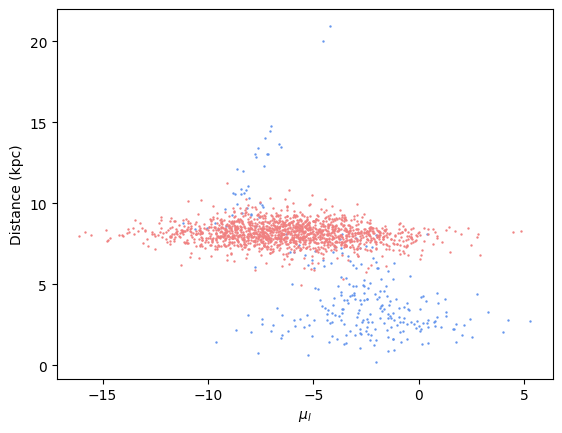

In [9]:
# Plot proper motion and distance
far_disk_from_color = df[((df[spfilt2] - df[spfilt1]) < colorcut) & (df['Dist'] > galcenter)]

plt.xlabel(r'$\mu_l$')
plt.ylabel("Distance (kpc)")
#plt.scatter(disk_mul, disk_df['Dist'], s=0.05, color="cornflowerblue")#, label="disk")
#plt.scatter(fardisk_mul, fardisk_df['Dist'], s=0.05, color="cornflowerblue")
#plt.scatter(bulge_mul, bulge_df['Dist'], s=0.05, color="lightcoral")#, label="bulge")
plt.scatter(df[df['pop'].isin(disk_pops)]['mul'], df[df['pop'].isin(disk_pops)]['Dist'], s=0.5, color="cornflowerblue")
plt.scatter(df[df['pop'] == bulge_pop]['mul'], df[df['pop'] == bulge_pop]['Dist'], s=0.5, color="lightcoral")
#plt.scatter(disk_mul[disk_df['pop'] == bulge_pop], disk_df[disk_df['pop'] == bulge_pop]["Dist"], s = 1., color = "blue", label = "color = blue, but pop = bulge")
#plt.scatter(bulge_mul[bulge_df['pop'].isin(disk_pops)], bulge_df[bulge_df['pop'].isin(disk_pops)]['Dist'], s=3., color="crimson", label="color = red, but pop = disk")
#plt.scatter(disk_mul[disk_df['pop'] == bulge_pop], disk_df[disk_df['pop'] == bulge_pop]["Dist"], s = 3., color = "blue", label = "color = blue, but pop = bulge")
#plt.legend()

Text(0.5, 0, 'Distance (kpc)')

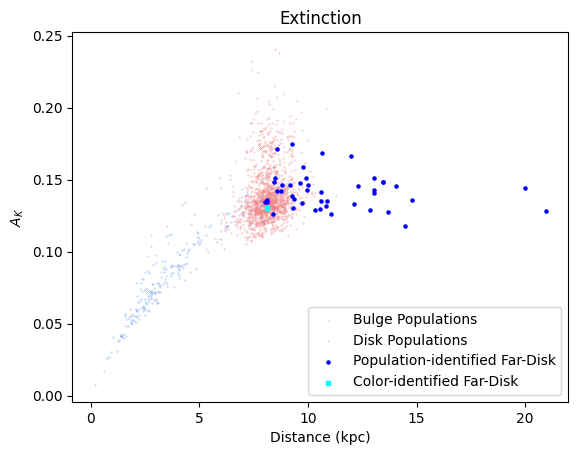

In [10]:
# Plot extinction
plt.title("Extinction")
plt.scatter(df[df['pop'] == bulge_pop]['Dist'], df[df['pop'] == bulge_pop]['A_Ks'], s=0.05, color="lightcoral", label = "Bulge Populations")
plt.scatter(df[df['pop'].isin(disk_pops)]['Dist'], df[df['pop'].isin(disk_pops)]['A_Ks'], s=0.05, color="cornflowerblue", label = "Disk Populations")
plt.scatter(df[df['pop'].isin(disk_pops) & (df['Dist'] > galcenter)]['Dist'], df[df['pop'].isin(disk_pops) & (df['Dist'] > galcenter)]['A_Ks'], s=5., color="blue", label = "Population-identified Far-Disk")
plt.scatter(far_disk_from_color['Dist'], far_disk_from_color['A_Ks'], s=5., color="cyan", marker = "s", label = "Color-identified Far-Disk")
#print(len(df[((df['Bessell_V'] - df['Bessell_I']) < colorcut) & (df['Dist'] > galcenter)]))
plt.legend()
plt.ylabel(r'$A_K$')
plt.xlabel("Distance (kpc)")

In [11]:
# Subtract median bulge proper motions to get a good proper motion zero point (because right now, I found pixel offsets in the archive by assuming the median mu of archive stars is zero, so I need to do that for SynthPop data)
mul_zeropt = np.median(bulge_mul)
mub_zeropt = np.median(bulge_mub)
print(f"zero points: ({mul_zeropt}, {mub_zeropt})")
bulge_mul = bulge_mul - mul_zeropt
bulge_mub = bulge_mub - mub_zeropt
disk_mul = disk_mul - mul_zeropt
disk_mub = disk_mub - mub_zeropt

zero points: (-6.170926700000001, -0.22235496)


Filename: kinematics/hlsp_wfc3bulge_hst_wfc3_stanek_multi_v2.0_cat.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  catalog       1 BinTableHDU    102   1R x 31C   [212634D, 212634D, 212634D, 212634D, 212634D, 212634D, 212634D, 212634D, 212634D, 212634D, 212634I, 212634D, 212634D, 212634D, 212634D, 212634I, 212634D, 212634D, 212634D, 212634D, 212634I, 212634D, 212634D, 212634D, 212634D, 212634I, 212634D, 212634D, 212634D, 212634D, 212634I]   
X range: 875.5535049262812 7188.645897537281
Y range: 717.5227012521577 7386.122989329157
μ_l*cos(b): -83.11220571832791 83.87391119127861
μ_b: -85.47373984724047 87.85709122058606
Number of data points: 212072
archive_mul min/max: -14.378627788342557 9.546404205539599
archive_mub min/max: -30.966598439242468 16.661772263611887

(std, mean)
Bulge: (2.945240872785576, -0.41032969867330343)
Disk: (2.3970352048598467, 4.039096443026803)

(std, mean)
Bulge: (2.6370989540529326, 

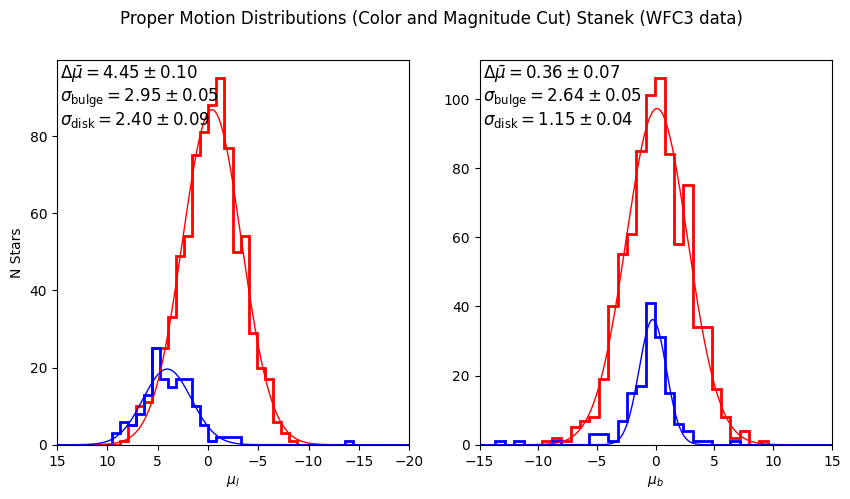

In [12]:
# Load archive data and plot histogram
if sep_idx == 1:
    archive_file = "kinematics/"+catalog_dict[window_idx][1]
    hdu = fits.open(archive_file)
    hdu.info()
    #w = WCS(hdu[0].header)
    #image_size = hdu[1].data.size
    #print(f"Image size: {image_size}")
    #print(hdu[1].columns)	# Print column names
    #print(w)
    #print("XPOS shape:", hdu[1].data["XPOS"].shape)
    #print("PPMX shape:", hdu[1].data["PPMX"].shape)
    image_x = hdu[1].data["XPOS"]
    image_y = hdu[1].data["YPOS"]

    print("X range:", image_x.min(), image_x.max())
    print("Y range:", image_y.min(), image_y.max())

    # Get initial pixel coordinates
    xpos1 = np.array(hdu[1].data["XPOS"], dtype=float)[0]
    ypos1 = np.array(hdu[1].data["YPOS"], dtype=float)[0]	

    # Get archive proper motion (mu) values
    ppmx_raw = np.array(hdu[1].data["PPMX"], dtype=float)[0]	# Proper motion [pixels] (not divided by baseline)
    ppmy_raw = np.array(hdu[1].data["PPMY"], dtype=float)[0]	# Proper motion [pixels] (not divided by baseline)
    good = (ppmx_raw != 999) & (ppmy_raw != 999) # Get rid of the data associated weird 999 value in PPMX
    ppmx_raw = ppmx_raw[good]
    ppmy_raw = ppmy_raw[good]
    #print(ppmx_raw)
    #print(hdu[1].data["RA"][0])
    #print(ppmx_raw.min(), ppmx_raw.max())
    #print(ppmy_raw.min(), ppmy_raw.max())
    
    #print("ppmx_raw min/max:", ppmx_raw.min(), ppmx_raw.max())
    #print("pixel_scale:", pixel_scale)
    #print("baseline:", baseline)

    # Get new pixel coordinates by adding proper motion to (x1, y1)
    #xpos2 = xpos1 + ppmx_raw
    #ypos2 = ypos1 + ppmy_raw

    # RA, Dec from archive
    ra = np.array(hdu[1].data["RA"], dtype=float)[0]
    dec = np.array(hdu[1].data["DEC"], dtype=float)[0]
    #print(f"Number of data points: {len(ra)}")

    # Get rid of the data associated with weird 999 value in PPMX
    xpos1 = xpos1[good]
    ypos1 = ypos1[good]
    ra = ra[good]
    dec = dec[good]

    # Define image reference coordinates (median star position)
    x0 = np.median(xpos1)
    y0 = np.median(ypos1)
    ra0 = np.median(ra)
    dec0 = np.median(dec)

    # Pixel offsets from reference
    dx = xpos1 - x0
    dy = ypos1 - y0

    # RA, Dec offsets from reference
    dra  = (ra - ra0) * np.cos(np.deg2rad(dec0)) * 3600 * 1000  # [mas]
    ddec = (dec - dec0) * 3600 * 1000 # [mas]

    # Offsets as vectors pointing from the defined median star position to each individual star position
    px_offset = np.vstack([dx, dy]).T
    radec_offset = np.vstack([dra, ddec]).T

    # Matrix containing offsets
    A, _, _, _ = np.linalg.lstsq(px_offset, radec_offset, rcond=None)
    #print(f"A: {A}")
    
    mu_x = ppmx_raw / baseline # Project pixel coordinates onto RA [pixels] * [mas/pixel] / [year] = [mas/yr]; units are actually [px/yr] cuz the pixel scale is now in A
    mu_y = ppmy_raw / baseline # Project pixel coordinates onto Dec [pixels] * [mas/pixel] / [year] = [mas/yr]; units are actually [px/yr] cuz the pixel scale is now in A
    #print(mu_x.min(), mu_x.max())

    # Proper motions in RA, Dec using offsets
    mu_ra_cosdec = A[0,0]*mu_x + A[0,1]*mu_y   # mas/yr
    mu_dec = A[1,0]*mu_x + A[1,1]*mu_y
    #print(np.std(mu_ra_cosdec), np.std(mu_dec))

    # Equitorial and galactic coordinates
    c_eq = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, pm_ra_cosdec=mu_ra_cosdec * u.mas/u.yr, pm_dec=mu_dec * u.mas/u.yr, frame="icrs")
    c_gal = c_eq.galactic

    # Archive proper motions
    archive_mul = c_gal.pm_l_cosb.to(u.mas/u.yr).value
    archive_mub = c_gal.pm_b.to(u.mas/u.yr).value
    print("μ_l*cos(b):", archive_mul.min(), archive_mul.max())
    print("μ_b:", archive_mub.min(), archive_mub.max())

    #ra_rad  = np.deg2rad(ra)
    #dec_rad = np.deg2rad(dec)

    #r_eq = np.vstack([np.cos(dec_rad)*np.cos(ra_rad), np.cos(dec_rad)*np.sin(ra_rad), np.sin(dec_rad)]).T
    
    # Define magnitude archive data variables
    archive_I = np.array(hdu[1].data["IMAG"], dtype=float)[0][good] # Define I magnitude (F814W) from archive data
    archive_V = np.array(hdu[1].data["VMAG"], dtype=float)[0][good] # Define V magnitude (F555W) from archive data
    archive_color = (archive_V - archive_I)[archive_I < arch_magcut] 
    print(f"Number of data points: {len(archive_I)}")
    #print(len(archive_color))

    # Apply magnitude cut
    archive_mul = archive_mul[archive_I < arch_magcut]
    archive_mub = archive_mub[archive_I < arch_magcut]
    #disk_df = df[(df['Bessell_V'] - df['Bessell_I']) < colorcut]
    #bulge_df = df[(df['Bessell_V'] - df['Bessell_I']) > colorcut]
    #print(len(archive_mul))
    #print(len(archive_mub))
    print("archive_mul min/max:", archive_mul.min(), archive_mul.max())
    print("archive_mub min/max:", archive_mub.min(), archive_mub.max())

    # Apply colorcut
    #arch_colorcut_dict = {
    #	0: 0.22,
    #	1: 0.28,
    #   2: 0.65,
    #	3: 0.3
    #}
    #arch_colorcut = arch_colorcut_dict[window_idx]

    # Separate into disk and bulge using colorcut
    bulge_mask = archive_color > arch_colorcut
    disk_mask = archive_color < arch_colorcut
    #arch_bulge_mul = archive_mul[archive_color > arch_colorcut]
    #arch_bulge_mub = archive_mub[archive_color > arch_colorcut]
    #arch_disk_mul = archive_mul[archive_color < arch_colorcut]
    #arch_disk_mub = archive_mub[archive_color < arch_colorcut]
    arch_bulge_mul = archive_mul[bulge_mask]
    arch_bulge_mub = archive_mub[bulge_mask]
    arch_disk_mul = archive_mul[disk_mask]
    arch_disk_mub = archive_mub[disk_mask]
    #arch_bulge_mul = archive_mul[archive_color > colorcut]
    #arch_bulge_mub = archive_mub[archive_color > colorcut]
    #arch_disk_mul = archive_mul[archive_color < colorcut]
    #arch_disk_mub = archive_mub[archive_color < colorcut]

    # Subtract median bulge proper motions to get a good proper motion zero point (because right now, I found pixel offsets by assuming the median mu of archive stars is zero)
    #mul_zeropt = np.median(arch_bulge_mul)
    #mub_zeropt = np.median(arch_bulge_mub)
    #print(f"zero points: ({mul_zeropt}, {mub_zeropt})")
    #arch_bulge_mul = arch_bulge_mul - mul_zeropt
    #arch_bulge_mub = arch_bulge_mub - mub_zeropt
    #arch_disk_mul = arch_disk_mul - mul_zeropt
    #arch_disk_mub = arch_disk_mub - mub_zeropt

    # Calculate bin edges for bulge and disk populations
    #####arch_bin_edges = np.arange(min(mul) - arch_bin_width, max(mul) + arch_bin_width, arch_bin_width)
    #arch_bin_edges = np.linspace(archive_mul.min(),archive_mul.max(),50)
    #####arch_bin_edges = np.arange(min(archive_mul) - arch_bin_width, max(archive_mul) + arch_bin_width, arch_bin_width)
    xmin = min(bin_edges.min(), archive_mul.min())
    xmax = max(bin_edges.max(), archive_mul.max())

    arch_bin_edges = np.arange(xmin, xmax + arch_bin_width, arch_bin_width)

    # Get fit parameters from fit function and ORGANIZE it all into a dictionary
    #arch_dict_l = {"bulge" : {}, "disk" : {}}
    #arch_dict_b = {"bulge" : {}, "disk" : {}}
    if fit == 1:
        arch_dict_l = {}
        arch_dict_b = {}
        arch_dict_l["bulge"] = dict(zip(["hist", "popt", "pcov"], gauss_fit(arch_bulge_mul, arch_bin_edges, 1)))
        arch_dict_l["disk"] = dict(zip(["hist", "popt", "pcov"], gauss_fit(arch_disk_mul, arch_bin_edges, 1)))
        arch_dict_b["bulge"] = dict(zip(["hist", "popt", "pcov"], gauss_fit(arch_bulge_mub, arch_bin_edges, 1)))
        arch_dict_b["disk"] = dict(zip(["hist", "popt", "pcov"], gauss_fit(arch_disk_mub, arch_bin_edges, 1)))
    else:
        arch_dict_l = {"bulge" : {}, "disk" : {}}
        arch_dict_b = {"bulge" : {}, "disk" : {}}
        arch_dict_l["bulge"]["hist"] = gauss_fit(arch_bulge_mul, arch_bin_edges, 1)
        arch_dict_l["disk"]["hist"] = gauss_fit(arch_disk_mul, arch_bin_edges, 1)
        arch_dict_b["bulge"]["hist"] = gauss_fit(arch_bulge_mub, arch_bin_edges, 1)
        arch_dict_b["disk"]["hist"] = gauss_fit(arch_disk_mub, arch_bin_edges, 1)

    #print(arch_dict_l)

    ##################### Plot archive data
    #x_space = np.linspace(arch_bin_edges.min(), arch_bin_edges.max(), 100000)
    x_space = np.linspace(-20, 20, 10000)

    arch_fig, (arch_ax1, arch_ax2) = plt.subplots(1, 2, figsize=(10, 5))
    arch_fig.suptitle("Proper Motion Distributions (Color and Magnitude Cut) "+window+" (WFC3 data)")

    #if norm == "True":
    	#print("checkpoint 1")
    #	arch_ax1.set_ylabel("N Stars")
    #else:
    #	arch_ax1.set_ylabel('stars / arcmin$^2$ / mag')
    arch_ax1.set_ylabel("N Stars")

    # Get the errors done
    if fit == 1:
        arch_dict_l = mean_and_err(arch_dict_l)
        arch_dict_b = mean_and_err(arch_dict_b)
        #print(arch_dict_l)

    ##### Plot mul
    arch_ax1.set_xlim(-20, 15)	# Set x-axis limits
    arch_ax1.set_xlabel(r'$\mu_l$')
    arch_ax1.invert_xaxis()	# Invert x-axis

    ##### Plot mub
    arch_ax2.set_xlabel(r'$\mu_b$')
    arch_ax2.set_xlim(-15, 15)
    #arch_ax2.invert_xaxis()	# Invert x-axis

    subplot(arch_ax1, arch_dict_l, arch_bin_edges, 1)
    subplot(arch_ax2, arch_dict_b, arch_bin_edges, 1)

    # Save as png
    #if norm == "True":
    	#fig.savefig("propermotionHist_popcut_"+window+"_Huston2025_norm.png")
    #else:
		#fig.savefig("propermotionHist_popcut_"+window+"_Huston2025.png")

    plt.show()		
    plt.close()

In [13]:
##### Get curve_fit params and things needed for plotting gaussian
# x space to plot gaussians
#x_space = np.linspace(bin_edges.min(), bin_edges.max(), 1000)

# Get fit parameters from fit function and ORGANIZE it all into a dictionary
data_dict_l = {}
data_dict_b = {}
data_dict_l["bulge"] = dict(zip(["hist", "popt", "pcov"], gauss_fit(bulge_mul, bin_edges, 0)))
data_dict_l["disk"] = dict(zip(["hist", "popt", "pcov"], gauss_fit(disk_mul, bin_edges, 0)))
data_dict_b["bulge"] = dict(zip(["hist", "popt", "pcov"], gauss_fit(bulge_mub, bin_edges, 0)))
data_dict_b["disk"] = dict(zip(["hist", "popt", "pcov"], gauss_fit(disk_mub, bin_edges, 0)))
#print(data_dict_l)

optimized parameters: [-0.35453843  2.90702818]
fit error: [0.00220495 0.0076833 ]
optimized parameters: [4.00408134 2.63950797]
fit error: [0.0122013  0.04244473]
optimized parameters: [0.01452187 3.12765044]
fit error: [0.00094832 0.00331052]
optimized parameters: [3.91895142 2.52927151]
fit error: [0.00474431 0.01654684]
optimized parameters: [0.0972432  2.53343572]
fit error: [0.00186922 0.00653877]
optimized parameters: [-0.39583032  1.12490765]
fit error: [0.00492132 0.0171518 ]
optimized parameters: [0.00769488 2.48107351]
fit error: [0.00101722 0.00356003]
optimized parameters: [-0.2759185   1.04434853]
fit error: [0.00282495 0.00988313]


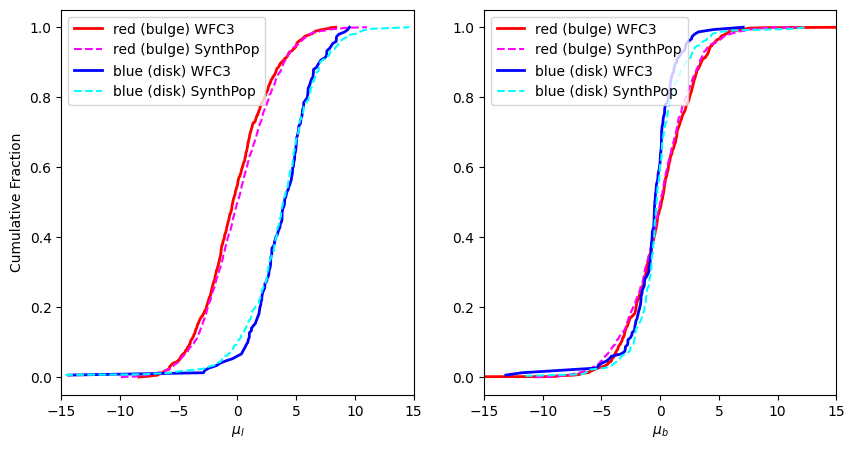

In [14]:
# Plotting and comparing cumulative distributions

# Dictionary -- trying to fix everything that makes my brain hurt and makes me want to drop out of the PhD program because I don't know how to code
proper_motion_dict = {
    "mu_l": {
        "hubble": {
            "bulge": arch_bulge_mul,
            "disk":  arch_disk_mul,
        },
        "synthpop": {
            "bulge": bulge_mul,
            "disk":  disk_mul,
        },
    },
    "mu_b": {
        "hubble": {
            "bulge": arch_bulge_mub,
            "disk":  arch_disk_mub,
        },
        "synthpop": {
            "bulge": bulge_mub,
            "disk":  disk_mub,
        },
    },
}

if sep_idx == 1:
    # Store things in dictionaries and stop copy-pasting every line 8 times
    l_dict = {}
    b_dict = {}
    cdf_dict = {"mu_l": l_dict, "mu_b": b_dict}

    for coordinate, coord_data in proper_motion_dict.items():
        #print(coord)
        #print(coord_data)
        #print()
        l_or_b_dict = cdf_dict[coordinate]
        #print(mul_or_mub)

        for catalog, cat_data in coord_data.items():
            #print(catalog)
            #print(cat_data)
            for population, pop_data in cat_data.items():
                l_or_b_dict.setdefault(population, {})
                l_or_b_dict[population].setdefault(catalog, {})

                # Prepare cdf data
                #l_or_b_dict[population][catalog]["sorted"] = np.sort(pop_data)
                sorted_data = np.sort(pop_data)

                #l_or_b_dict[population][catalog]["cdf"] = np.arange(1, len(l_or_b_dict[population][catalog]["sorted"])+1) / len(l_or_b_dict[population][catalog]["sorted"])
                cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
                l_or_b_dict[population][catalog]["sorted"] = sorted_data
                l_or_b_dict[population][catalog]["cdf"] = {}
                l_or_b_dict[population][catalog]["cdf"]["data"] = cdf

                # Fit gaussian to cdf median
                #l_or_b_dict[population][catalog]["cdf"]["mu"], l_or_b_dict[population][catalog]["cdf"]["sigma"] = gaussian_cdf_fit(l_or_b_dict[population][catalog]["sorted"], l_or_b_dict[population][catalog]["cdf"])
                mu, sigma, mu_err, sigma_err = gaussian_cdf_fit(sorted_data, cdf)
                l_or_b_dict[population][catalog]["cdf"]["mu"] = mu
                l_or_b_dict[population][catalog]["cdf"]["sigma"] = sigma
                l_or_b_dict[population][catalog]["cdf"]["mu_err"] = mu_err
                l_or_b_dict[population][catalog]["cdf"]["sigma_err"] = sigma_err
                
    # Maybe do a dictionary to save plotting arguments?
    #l_or_b_dict[population][catalog]["cdf"]["plot_args"] = []

    # Plot
    cdf_fig, (cdf_ax1, cdf_ax2) = plt.subplots(1, 2, figsize=(10, 5))

    cdf_axes = {
        "mu_l": (cdf_ax1, l_dict),
        "mu_b": (cdf_ax2, b_dict),
    }

    cdf_plot_args = {
        ("bulge", "hubble"):    dict(color="red",    linestyle="-",  linewidth=2,   label="red (bulge) WFC3"),
        ("bulge", "synthpop"): dict(color="magenta", linestyle="--", linewidth=1.5, label="red (bulge) SynthPop"),
        ("disk",  "hubble"):   dict(color="blue",   linestyle="-",  linewidth=2,   label="blue (disk) WFC3"),
        ("disk",  "synthpop"): dict(color="cyan",   linestyle="--", linewidth=1.5, label="blue (disk) SynthPop"),
    }

    for (ax, data_dict) in cdf_axes.values():
        for (population, catalog), plot_arg in cdf_plot_args.items():
            ax.plot(data_dict[population][catalog]["sorted"], data_dict[population][catalog]["cdf"]["data"], **plot_arg)

    '''
    cdf_ax1.plot(l_dict["bulge"]["hubble"]["sorted"], l_dict["bulge"]["hubble"]["cdf"]["data"], color = "red", label="red (bulge) WFC3")
    cdf_ax1.plot(l_dict["bulge"]["synthpop"]["sorted"], l_dict["bulge"]["synthpop"]["cdf"]["data"], linestyle="--", linewidth=1.5, color = "magenta", label="red (bulge) SynthPop")
    cdf_ax1.plot(l_dict["disk"]["hubble"]["sorted"], l_dict["disk"]["hubble"]["cdf"]["data"], color = "blue", label="blue (disk) WFC3")
    cdf_ax1.plot(l_dict["disk"]["synthpop"]["sorted"],  l_dict["disk"]["synthpop"]["cdf"]["data"],  linestyle="--", linewidth=1.5, color = "cyan", label="blue (disk) SynthPop")

    cdf_ax2.plot(b_dict["bulge"]["hubble"]["sorted"], b_dict["bulge"]["hubble"]["cdf"]["data"], color = "red", label="red (bulge) WFC3")
    cdf_ax2.plot(b_dict["bulge"]["synthpop"]["sorted"], b_dict["bulge"]["synthpop"]["cdf"]["data"], linestyle="--", linewidth=1.5, color = "magenta", label="red (bulge) SynthPop")
    cdf_ax2.plot(b_dict["disk"]["hubble"]["sorted"], b_dict["disk"]["hubble"]["cdf"]["data"], color = "blue", label="blue (disk) WFC3")
    cdf_ax2.plot(b_dict["disk"]["synthpop"]["sorted"], b_dict["disk"]["synthpop"]["cdf"]["data"],  linestyle="--", linewidth=1.5, color = "cyan", label="blue (disk) SynthPop")
    '''
    
    cdf_ax1.set_xlim(-15, 15)	# Set x-axis limits
    cdf_ax2.set_xlim(-15, 15)
    
    cdf_ax1.set_ylabel("Cumulative Fraction")
    cdf_ax1.set_xlabel(r'$\mu_l$')
    cdf_ax2.set_xlabel(r'$\mu_b$')
    cdf_ax1.legend()
    cdf_ax2.legend()
    #plt.legend()
    plt.show()
    plt.close()

    # Plot fits
    ########
    '''
    cdf_fit_plot_args = {
        ("hubble", "fit"):    dict(linewidth = 0.6, color = "red", label = "WFC3 fit"),
        ("synthpop", "fit"): dict(linewidth = 0.6, color = "magenta", label = "SynthPop fit"),
        ("hubble", "data"):   dict(linestyle = "dotted", linewidth = 2, color = "maroon", label="red (bulge) WFC3"),
        ("synthpop", "data"): dict(linestyle="dashdot", linewidth=2, color = "darkviolet", label="red (bulge) SynthPop"),
    }
    
    fit_xspace = np.linspace(-15, 15, 500)
    plt.axhline(cdf_median_range[0], color="silver", linewidth = 0.5, linestyle="-")#, label="Median fit range")
    plt.axhline(cdf_median_range[1], color="silver", linewidth = 0.5, linestyle="-")
    plt.axhspan(cdf_median_range[0], cdf_median_range[1], facecolor='gainsboro', alpha=0.5)
    #plt.plot(fit_xspace, gaussian_cdf(fit_xspace, mu_arch_bulge_mul, sig_arch_bulge_mul), linewidth = 0.6, color = "red", label = "WFC3 fit")
    #plt.plot(fit_xspace, gaussian_cdf(fit_xspace, mu_bulge_mul, sig_bulge_mul), linewidth = 0.6, color = "magenta", label = "SynthPop fit")
    plt.plot(fit_xspace, gaussian_cdf(fit_xspace, l_dict["bulge"]["hubble"]["cdf"]["mu"], l_dict["bulge"]["hubble"]["cdf"]["sigma"]), linewidth = 0.6, color = "red", label = "WFC3 fit")
    plt.plot(fit_xspace, gaussian_cdf(fit_xspace, l_dict["bulge"]["synthpop"]["cdf"]["mu"], l_dict["bulge"]["synthpop"]["cdf"]["sigma"]), linewidth = 0.6, color = "magenta", label = "SynthPop fit")
    #plt.plot(arch_mul_bulge_sorted, arch_mul_bulge_cdf, linestyle = "dotted", linewidth = 2, color = "maroon", label="red (bulge) WFC3")
    #plt.plot(mul_bulge_sorted,  mul_bulge_cdf,  linestyle="dashdot", linewidth=2, color = "darkviolet", label="red (bulge) SynthPop")
    plt.plot(l_dict["bulge"]["hubble"]["sorted"], l_dict["bulge"]["hubble"]["cdf"]["data"], linestyle = "dotted", linewidth = 2, color = "maroon", label="red (bulge) WFC3")
    plt.plot(l_dict["bulge"]["synthpop"]["sorted"], l_dict["bulge"]["synthpop"]["cdf"]["data"], linestyle="dashdot", linewidth=2, color = "darkviolet", label="red (bulge) SynthPop")
    plt.text(2.5, 0.2, s=rf'$\mu_{{\mathrm{{hubble}}}} = {l_dict["bulge"]["hubble"]["cdf"]["mu"]:.2f} \pm {l_dict["bulge"]["hubble"]["cdf"]["mu_err"]:.2f}$', fontsize=10, ha='left', va='top')#, transform=ax.transAxes)
    plt.text(2.5, 0.15, s=rf'$\mu_{{\mathrm{{sp}}}} = {l_dict["bulge"]["synthpop"]["cdf"]["mu"]:.2f} \pm {l_dict["bulge"]["synthpop"]["cdf"]["mu_err"]:.2f}$', fontsize=10, ha='left', va='top')#, transform=ax.transAxes)
    plt.text(2.5, 0.10, s=rf'$\sigma_{{\mathrm{{hubble}}}} = {l_dict["bulge"]["hubble"]["cdf"]["sigma"]:.2f} \pm {l_dict["bulge"]["hubble"]["cdf"]["sigma_err"]:.2f}$', fontsize=10, ha='left', va='top')#, transform=ax.transAxes)
    plt.text(2.5, 0.05, s=rf'$\sigma_{{\mathrm{{sp}}}} = {l_dict["bulge"]["synthpop"]["cdf"]["sigma"]:.2f} \pm {l_dict["bulge"]["synthpop"]["cdf"]["sigma_err"]:.2f}$', fontsize=10, ha='left', va='top')#, transform=ax.transAxes)
    plt.xlim(-10, 10)	# Set x-axis limits
    plt.ylabel("Cumulative Fraction")
    plt.xlabel(r'$\mu_l$')
    plt.legend()
    plt.show()

    # Do subplots
    #cdf_fit_fig, (cdf_fit_ax1, cdf_fit_ax2, cdf_fit_ax3, cdf_fit_ax4) = plt.subplots(2,2, figsize=(15, 10))
    cdf_fit_fig, cdf_fit_axs = plt.subplots(2,2, figsize=(15, 10))
    cdf_fit_topleft = cdf_fit_axs[0,0]
    cdf_fit_topright = cdf_fit_axs[0,1]
    cdf_fit_bottomleft = cdf_fit_axs[1,0]
    cdf_fit_bottomright = cdf_fit_axs[1,1]
    
    # Plot things that should be in all subplots
    for ax in cdf_fit_axs.flat:
        ax.axhline(cdf_median_range[0], color="silver", linewidth = 0.5, linestyle="-")#, label="Median fit range")
        ax.axhline(cdf_median_range[1], color="silver", linewidth = 0.5, linestyle="-")
        ax.axhspan(cdf_median_range[0], cdf_median_range[1], facecolor='gainsboro', alpha=0.5)
        ax.set_xlim(-7.5, 10.5)

    cdf_fit_axes = {
        ("mu_l", "bulge"): (cdf_fit_topleft, "bulge", l_dict),
        ("mu_b", "bulge"): (cdf_fit_topright, "bulge", b_dict),
        ("mu_l", "disk"): (cdf_fit_bottomleft, "disk", l_dict),
        ("mu_b", "disk"): (cdf_fit_bottomright, "disk", b_dict),
    }

    for (ax, population, data_dict) in cdf_fit_axes.values():
        #print(cdf_fit_axes)
        for (catalog, fit_or_data), plot_arg in cdf_fit_plot_args.items():
            #print(fit_or_data)
            #print(catalog)
            #print(plot_arg)
            ax.plot(fit_xspace, gaussian_cdf(fit_xspace, data_dict[population][catalog]["cdf"]["mu"], data_dict[population][catalog]["cdf"]["sigma"]), **plot_arg)
            ax.plot(data_dict[population][catalog]["sorted"], data_dict[population][catalog]["cdf"]["data"], **plot_arg)
            

    cdf_fit_topleft.set_ylabel("Cumulative Fraction")
    cdf_fit_bottomleft.set_ylabel("Cumulative Fraction")
    cdf_fit_bottomleft.set_xlabel(r'$\mu_l$')
    cdf_fit_bottomright.set_xlabel(r'$\mu_b$')
    '''

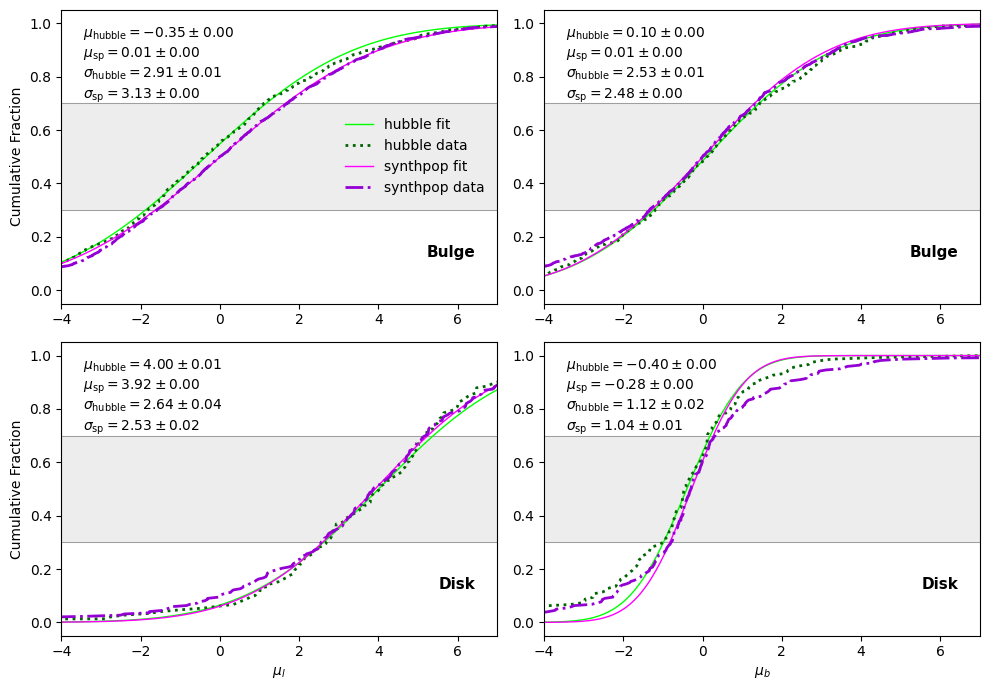

In [15]:
if sep_idx == 1:
    fit_xspace = np.linspace(-15, 15, 500)
    cdf_fit_fig, cdf_fit_axs = plt.subplots(2,2, figsize=(10, 7))
    
    axes_map = {
        ("mu_l", "bulge"): cdf_fit_axs[0, 0],
        ("mu_b", "bulge"): cdf_fit_axs[0, 1],
        ("mu_l", "disk"):  cdf_fit_axs[1, 0],
        ("mu_b", "disk"):  cdf_fit_axs[1, 1],
    }

    dict_map = {
        "mu_l": l_dict,
        "mu_b": b_dict,
    }

    colors = {
        "hubble":    dict(data="darkgreen",   fit="lime"),
        "synthpop":  dict(data="darkviolet", fit="magenta"),
    }

    # linestyles for DATA only
    data_linestyle = {
        "hubble": ":",
        "synthpop": "-."
    }

    '''
    lines = [
        rf'$\mu_{{\mathrm{{hubble}}}} = {l_dict["bulge"]["hubble"]["cdf"]["mu"]:.2f} \pm {l_dict["bulge"]["hubble"]["cdf"]["mu_err"]:.2f}$',
        rf'$\mu_{{\mathrm{{sp}}}} = {l_dict["bulge"]["synthpop"]["cdf"]["mu"]:.2f} \pm {l_dict["bulge"]["synthpop"]["cdf"]["mu_err"]:.2f}$',
        rf'$\sigma_{{\mathrm{{hubble}}}} = {l_dict["bulge"]["hubble"]["cdf"]["sigma"]:.2f} \pm {l_dict["bulge"]["hubble"]["cdf"]["sigma_err"]:.2f}$',
        rf'$\sigma_{{\mathrm{{sp}}}} = {l_dict["bulge"]["synthpop"]["cdf"]["sigma"]:.2f} \pm {l_dict["bulge"]["synthpop"]["cdf"]["sigma_err"]:.2f}$'
    ]
    '''

    y0 = 0.95
    dy = 0.07

    for (coord, population), ax in axes_map.items():
        data_dict = dict_map[coord]

        # median region
        ax.axhspan(*cdf_median_range, color="gainsboro", alpha=0.5)
        ax.axhline(cdf_median_range[0], color="gray", lw=0.5)
        ax.axhline(cdf_median_range[1], color="gray", lw=0.5)

        for catalog in ["hubble", "synthpop"]:
            entry = data_dict[population][catalog]["cdf"]

            # fit
            ax.plot(
                fit_xspace,
                gaussian_cdf(fit_xspace, entry["mu"], entry["sigma"]),
                linewidth=1,
                color=colors[catalog]["fit"],
                label=f"{catalog} fit" if population == "bulge" else None
            )
            
            # data
            ax.plot(
                data_dict[population][catalog]["sorted"],
                entry["data"],
                linestyle=data_linestyle[catalog],
                linewidth=2,
                color=colors[catalog]["data"],
                label=f"{catalog} data" if population == "bulge" else None
            )

        ax.set_xlim(-4., 7.)

        lines = [
            rf'$\mu_{{\mathrm{{hubble}}}} = {data_dict[population]["hubble"]["cdf"]["mu"]:.2f} \pm '
            rf'{data_dict[population]["hubble"]["cdf"]["mu_err"]:.2f}$',
            rf'$\mu_{{\mathrm{{sp}}}} = {data_dict[population]["synthpop"]["cdf"]["mu"]:.2f} \pm '
            rf'{data_dict[population]["synthpop"]["cdf"]["mu_err"]:.2f}$',
            rf'$\sigma_{{\mathrm{{hubble}}}} = {data_dict[population]["hubble"]["cdf"]["sigma"]:.2f} \pm '
            rf'{data_dict[population]["hubble"]["cdf"]["sigma_err"]:.2f}$',
            rf'$\sigma_{{\mathrm{{sp}}}} = {data_dict[population]["synthpop"]["cdf"]["sigma"]:.2f} \pm '
            rf'{data_dict[population]["synthpop"]["cdf"]["sigma_err"]:.2f}$',
        ]

        for i, line in enumerate(lines):
            ax.text(
                0.05, y0 - i * dy,
                line,
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=10
            )

        ax.text(
            0.95, 0.2,
            population.capitalize(),
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            fontweight="bold"
        )
    
    # labels
    cdf_fit_axs[0, 0].set_ylabel("Cumulative Fraction")
    cdf_fit_axs[1, 0].set_ylabel("Cumulative Fraction")
    cdf_fit_axs[1, 0].set_xlabel(r"$\mu_l$")
    cdf_fit_axs[1, 1].set_xlabel(r"$\mu_b$")

    cdf_fit_axs[0, 0].legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [16]:
'''
# Plotting and comparing cumulative distributions - terrible
if sep_idx == 1:
    def get_cdf(hist):
        cdf_counts = np.cumsum(hist)
        cdf = cdf_counts / cdf_counts[-1] # Normalize
        return cdf

    # Subtract median bulge proper motions to get a good proper motion zero point (because right now, I found pixel offsets in the archive by assuming the median mu of archive stars is zero, so I need to do that for SynthPop data)
    #mul_zeropt = np.median(arch_bulge_mul)
    #mub_zeropt = np.median(arch_bulge_mub)
    #print(f"zero points: ({mul_zeropt}, {mub_zeropt})")
    #arch_bulge_mul = arch_bulge_mul - mul_zeropt
    #arch_bulge_mub = arch_bulge_mub - mub_zeropt
    #arch_disk_mul = arch_disk_mul - mul_zeropt
    #arch_disk_mub = arch_disk_mub - mub_zeropt
    
    # Forget that you ever did a separate bin edge thing for the archive
    #arch_bin_edges = bin_edges.copy()
    #arch_bin_centers = (arch_bin_edges[:-1] + arch_bin_edges[1:]) / 2
    # I'm pretty sure that all of the archive bins are the same and I just wrote the same thing 4 different times to that dictionary because I have no idea what I'm doing and I'm too lazy to figure out any other way of doing this
    #arch_bin_edges = arch_dict_l["bulge"]["edges"]
    #arch_bin_centers = 0.5 * (arch_bin_edges[:-1] + arch_bin_edges[1:])
    #####arch_bin_edges = bin_edges.copy()
    arch_bin_centers = 0.5 * (arch_bin_edges[:-1] + arch_bin_edges[1:])
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Regenerate histogram shit
    arch_dict_l["bulge"]["hist"] = np.histogram(arch_bulge_mul, bins=arch_bin_edges)[0]
    arch_dict_l["disk"]["hist"]  = np.histogram(arch_disk_mul,  bins=arch_bin_edges)[0]
    arch_dict_b["bulge"]["hist"] = np.histogram(arch_bulge_mub, bins=arch_bin_edges)[0]
    arch_dict_b["disk"]["hist"]  = np.histogram(arch_disk_mub,  bins=arch_bin_edges)[0]
    print("Archive min:", archive_mul.min())
    print("Bin min:", arch_bin_edges.min())

    # Archive data
    arch_dict_l["bulge"]["cdf"] = get_cdf(arch_dict_l["bulge"]["hist"])
    arch_dict_l["disk"]["cdf"] = get_cdf(arch_dict_l["disk"]["hist"])
    arch_dict_b["bulge"]["cdf"] = get_cdf(arch_dict_b["bulge"]["hist"])
    arch_dict_b["disk"]["cdf"] = get_cdf(arch_dict_b["disk"]["hist"])

    # SynthPop catalog
    data_dict_l["bulge"]["cdf"] = get_cdf(data_dict_l["bulge"]["hist"])
    data_dict_l["disk"]["cdf"] = get_cdf(data_dict_l["disk"]["hist"])
    data_dict_b["bulge"]["cdf"] = get_cdf(data_dict_b["bulge"]["hist"])
    data_dict_b["disk"]["cdf"] = get_cdf(data_dict_b["disk"]["hist"])

    # Fit Gaussian to median cumulative distribution function
    #arch_dict_l["bulge"]["cdf_popt"] = gauss_cdf_fit(arch_bin_centers, arch_dict_l["bulge"]["cdf"], *median_range_lb)
    #arch_dict_l["disk"]["cdf_popt"] = gauss_cdf_fit(arch_bin_centers, arch_dict_l["disk"]["cdf"], *median_range_ld)
    #arch_dict_b["bulge"]["cdf_popt"] = gauss_cdf_fit(arch_bin_centers, arch_dict_l["bulge"]["cdf"], *median_range_bb)
    #arch_dict_b["disk"]["cdf_popt"] = gauss_cdf_fit(arch_bin_centers, arch_dict_l["disk"]["cdf"], *median_range_bd)
    #print(arch_dict_l["bulge"]["cdf_popt"])

    cdf_fig, (cdf_ax1, cdf_ax2) = plt.subplots(1, 2, figsize=(10, 5))

    cdf_ax1.plot(arch_bin_centers, arch_dict_l["bulge"]["cdf"], color = 'red', label=r'red (bulge) WFC3')
    cdf_ax1.plot(arch_bin_centers, arch_dict_l["disk"]["cdf"], color = "blue", label=r'blue (disk) WFC3')
    cdf_ax2.plot(arch_bin_centers, arch_dict_b["bulge"]["cdf"], color = 'red', label=r'red (bulge) WFC3')
    cdf_ax2.plot(arch_bin_centers, arch_dict_b["disk"]["cdf"], color = "blue", label=r'blue (disk) WFC3')

    cdf_ax1.plot(bin_centers, data_dict_l["bulge"]["cdf"], color = 'magenta', linestyle = "--", label=r'red (bulge) SynthPop')
    cdf_ax1.plot(bin_centers, data_dict_l["disk"]["cdf"], color = "cyan", linestyle = "--", label=r'blue (disk) SynthPop')
    cdf_ax2.plot(bin_centers, data_dict_b["bulge"]["cdf"], color = 'magenta', linestyle = "--", label=r'red (bulge) SynthPop')
    cdf_ax2.plot(bin_centers, data_dict_b["disk"]["cdf"], color = "cyan", linestyle = "--", label=r'blue (disk) SynthPop')

    cdf_ax1.set_xlim(-20, 10)	# Set x-axis limits
    cdf_ax2.set_xlim(-15, 15)
    
    cdf_ax1.set_ylabel("Cumulative Fraction")
    cdf_ax1.set_xlabel(r'$\mu_l$')
    cdf_ax2.set_xlabel(r'$\mu_b$')
    cdf_ax1.legend()
    cdf_ax2.legend()
    #plt.legend()
    plt.show()
    plt.close()

    #plt.plot(arch_bin_centers, arch_dict_l["disk"]["cdf"] - data_dict_l["disk"]["cdf"], color = "blue", label="archive-SynthPop (disk)")
    #plt.plot(arch_bin_centers, arch_dict_l["bulge"]["cdf"] - data_dict_l["bulge"]["cdf"], color = "red", label="archive-SynthPop (bulge)")
    #plt.show()
    #plt.close()

    #plt.plot(arch_bin_centers, arch_dict_l["disk"]["cdf"] / data_dict_l["disk"]["cdf"], color = "blue", label="archive-SynthPop (disk)")
    #plt.plot(arch_bin_centers, arch_dict_l["bulge"]["cdf"] / data_dict_l["bulge"]["cdf"], color = "red", label="archive-SynthPop (bulge)")
'''

'\n# Plotting and comparing cumulative distributions - terrible\nif sep_idx == 1:\n    def get_cdf(hist):\n        cdf_counts = np.cumsum(hist)\n        cdf = cdf_counts / cdf_counts[-1] # Normalize\n        return cdf\n\n    # Subtract median bulge proper motions to get a good proper motion zero point (because right now, I found pixel offsets in the archive by assuming the median mu of archive stars is zero, so I need to do that for SynthPop data)\n    #mul_zeropt = np.median(arch_bulge_mul)\n    #mub_zeropt = np.median(arch_bulge_mub)\n    #print(f"zero points: ({mul_zeropt}, {mub_zeropt})")\n    #arch_bulge_mul = arch_bulge_mul - mul_zeropt\n    #arch_bulge_mub = arch_bulge_mub - mub_zeropt\n    #arch_disk_mul = arch_disk_mul - mul_zeropt\n    #arch_disk_mub = arch_disk_mub - mub_zeropt\n\n    # Forget that you ever did a separate bin edge thing for the archive\n    #arch_bin_edges = bin_edges.copy()\n    #arch_bin_centers = (arch_bin_edges[:-1] + arch_bin_edges[1:]) / 2\n    # I\'m


(std, mean)
Bulge: (3.0879369865852784, 0.003037562835650617)
Disk: (2.5073216092264192, 4.0090825624414785)

(std, mean)
Bulge: (2.5427243893722147, 0.07511521017899993)
Disk: (0.9629025031356843, -0.2835233249054804)
False
False


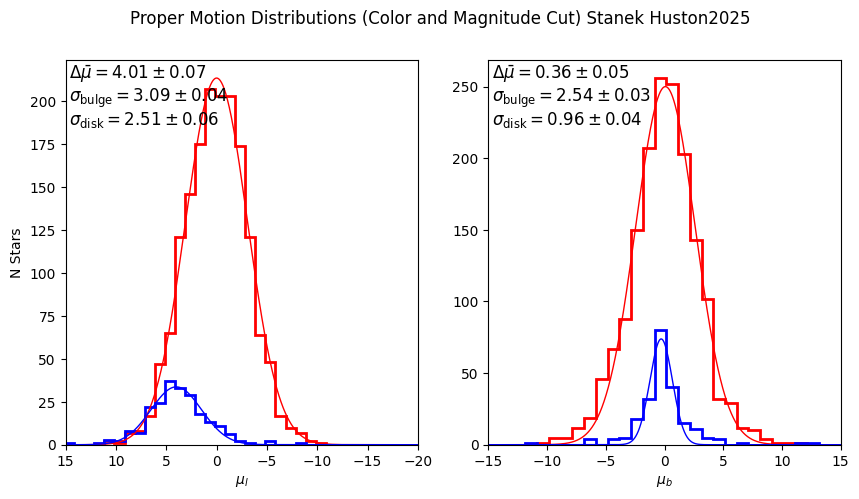

In [17]:
################ Separated Histogram Plotting ################
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
#fig.suptitle("Proper Motion Distributions (Pop Index and Distance Cut) "+window+" Huston2025")
if sep_idx == 0:
	fig.suptitle("Proper Motion Distributions (Pop Index and Distance Cut) "+window+" Huston2025")
elif sep_idx == 1:
	fig.suptitle("Proper Motion Distributions (Color and Magnitude Cut) "+window+" Huston2025")

#if norm == "True":
	#print("checkpoint 1")
#	ax1.set_ylabel("N Stars")
#else:
#	ax1.set_ylabel('stars / arcmin$^2$ / mag')
ax1.set_ylabel("N Stars")

# Get the errors done
data_dict_l = mean_and_err(data_dict_l)
data_dict_b = mean_and_err(data_dict_b)
#print(data_dict_l)

##### Plot mul
ax1.set_xlim(-20, 15)	# Set x-axis limits
ax1.set_xlabel(r'$\mu_l$')
ax1.invert_xaxis()	# Invert x-axis

##### Plot mub
ax2.set_xlabel(r'$\mu_b$')
ax2.set_xlim(-15, 15)

subplot(ax1, data_dict_l, bin_edges, 0)
subplot(ax2, data_dict_b, bin_edges, 0)

# Save as png
if sep_idx == 0:
	if norm == "True":
		fig.savefig("propermotionHist_popcut_"+window+"_Huston2025_norm.png")
	else:
		fig.savefig("propermotionHist_popcut_"+window+"_Huston2025.png")
elif sep_idx == 1:
	if norm == "True":
		fig.savefig("propermotionHist_CMcut_"+window+"_Huston2025_norm.png")
	else:
		fig.savefig("propermotionHist_CMcut_"+window+"_Huston2025.png")
plt.show()		
plt.close()


(std, mean)
Bulge: (3.0879370326673095, 0.0030387807634381175)
Disk: (2.507321610412184, 4.00908256203263)

(std, mean)
Bulge: (2.5427243866482283, 0.07511522700167816)
Disk: (0.9629025078558895, -0.2835233217531941)

(std, mean)
Bulge: (2.945240876092171, -0.4103296933163833)
Disk: (2.397035205049323, 4.039096446596952)

(std, mean)
Bulge: (2.6370989546672976, 0.09906683192651176)
Disk: (1.1536566270419575, -0.2572089956515509)
True
True
False
False


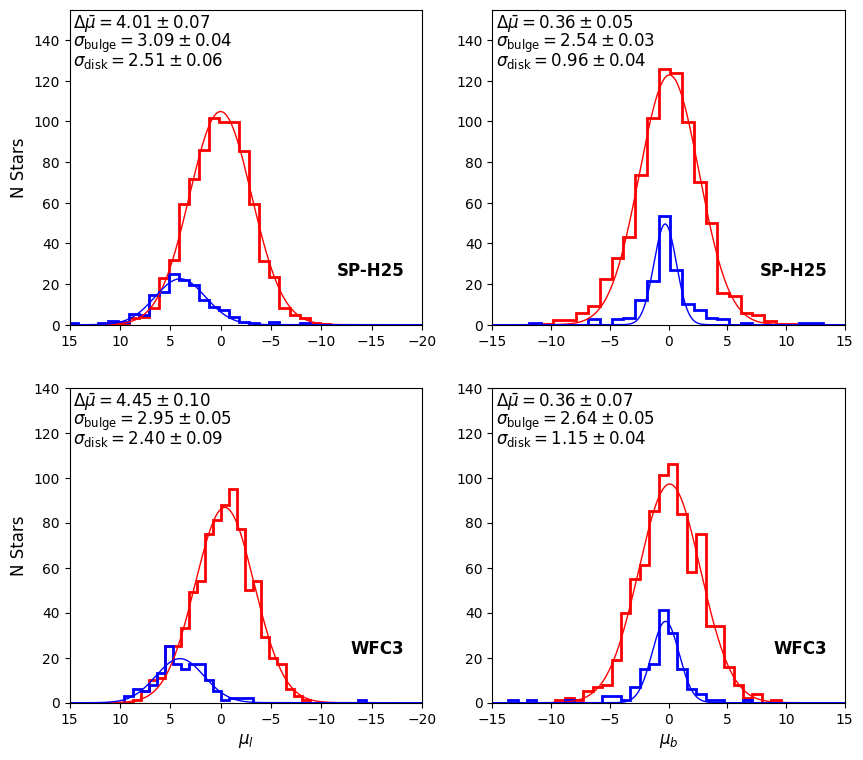

Proper motion peak separation in l agrees within 3.524324395477846 sigma
Proper motion peak separation in b agrees within 0.027932588355145255 sigma
Proper motion bulge dispersion in l agrees within 2.305540831584944 sigma
Proper motion disk dispersion in l agrees within 1.0069175183716887 sigma
Proper motion bulge dispersion in b agrees within 1.4590152583602534 sigma
Proper motion disk dispersion in b agrees within 3.5240040952205347 sigma


In [18]:
# Plot all 4 histograms together

# Normalization factor
#print(data_dict_l)
hubble_sp_norm_factor_lbulge = np.sum(arch_dict_l["bulge"]["hist"]) / np.sum(data_dict_l["bulge"]["hist"])
hubble_sp_norm_factor_ldisk = np.sum(arch_dict_l["disk"]["hist"]) / np.sum(data_dict_l["disk"]["hist"])
hubble_sp_norm_factor_bbulge = np.sum(arch_dict_b["bulge"]["hist"]) / np.sum(data_dict_b["bulge"]["hist"])
hubble_sp_norm_factor_bdisk = np.sum(arch_dict_b["disk"]["hist"]) / np.sum(data_dict_b["disk"]["hist"])
#print(hubble_sp_norm_factor_lbulge)

# Fit normalized data
#data_dict_l["bulge"] = dict(zip(["norm_hist", "norm_popt", "norm_pcov"], gauss_fit(bulge_mul, bin_edges, 0, hubble_sp_norm_factor_lbulge)))
#data_dict_l["disk"] = dict(zip(["norm_hist", "norm_popt", "norm_pcov"], gauss_fit(disk_mul, bin_edges, 0, hubble_sp_norm_factor_ldisk)))
#data_dict_b["bulge"] = dict(zip(["norm_hist", "norm_popt", "norm_pcov"], gauss_fit(bulge_mub, bin_edges, 0, hubble_sp_norm_factor_bbulge)))
#data_dict_b["disk"] = dict(zip(["norm_hist", "norm_popt", "norm_pcov"], gauss_fit(disk_mub, bin_edges, 0, hubble_sp_norm_factor_bdisk)))
#arch_dict_l["bulge"] = dict(zip(["norm_hist", "norm_popt", "norm_pcov"], gauss_fit(arch_bulge_mul, arch_bin_edges, 1, hubble_sp_norm_factor_lbulge)))
#arch_dict_l["disk"] = dict(zip(["norm_hist", "norm_popt", "norm_pcov"], gauss_fit(arch_disk_mul, arch_bin_edges, 1, hubble_sp_norm_factor_ldisk)))
#arch_dict_b["bulge"] = dict(zip(["norm_hist", "norm_popt", "norm_pcov"], gauss_fit(arch_bulge_mub, arch_bin_edges, 1, hubble_sp_norm_factor_bbulge)))
#arch_dict_b["disk"] = dict(zip(["norm_hist", "norm_popt", "norm_pcov"], gauss_fit(arch_disk_mub, arch_bin_edges, 1, hubble_sp_norm_factor_bdisk)))
data_dict_l["bulge"].update(
    dict(zip(["norm_hist", "norm_popt", "norm_pcov"],
             gauss_fit(bulge_mul, bin_edges, 0, hubble_sp_norm_factor_lbulge)))
)

data_dict_l["disk"].update(
    dict(zip(["norm_hist", "norm_popt", "norm_pcov"],
             gauss_fit(disk_mul, bin_edges, 0, hubble_sp_norm_factor_ldisk)))
)

data_dict_b["bulge"].update(
    dict(zip(["norm_hist", "norm_popt", "norm_pcov"],
             gauss_fit(bulge_mub, bin_edges, 0, hubble_sp_norm_factor_bbulge)))
)

data_dict_b["disk"].update(
    dict(zip(["norm_hist", "norm_popt", "norm_pcov"],
             gauss_fit(disk_mub, bin_edges, 0, hubble_sp_norm_factor_bdisk)))
)

arch_dict_l["bulge"].update(
    dict(zip(["norm_hist", "norm_popt", "norm_pcov"],
             gauss_fit(arch_bulge_mul, arch_bin_edges, 1, hubble_sp_norm_factor_lbulge)))
)

arch_dict_l["disk"].update(
    dict(zip(["norm_hist", "norm_popt", "norm_pcov"],
             gauss_fit(arch_disk_mul, arch_bin_edges, 1, hubble_sp_norm_factor_ldisk)))
)

arch_dict_b["bulge"].update(
    dict(zip(["norm_hist", "norm_popt", "norm_pcov"],
             gauss_fit(arch_bulge_mub, arch_bin_edges, 1, hubble_sp_norm_factor_bbulge)))
)

arch_dict_b["disk"].update(
    dict(zip(["norm_hist", "norm_popt", "norm_pcov"],
             gauss_fit(arch_disk_mub, arch_bin_edges, 1, hubble_sp_norm_factor_bdisk)))
)

#print(data_dict_l)

# Get mean and errors for normalized data
data_dict_l = mean_and_err(data_dict_l, True)
data_dict_b = mean_and_err(data_dict_b, True)
arch_dict_l = mean_and_err(arch_dict_l, True)
arch_dict_b = mean_and_err(arch_dict_b, True)
#print(data_dict_l)

hist_fig, hist_axs = plt.subplots(2,2, figsize=(10, 9))

hist_ax1 = hist_axs[0, 0]
hist_ax2 = hist_axs[0, 1]
hist_ax3 = hist_axs[1, 0]
hist_ax4 = hist_axs[1, 1]


hist_ax1.set_xlim(-20, 15)	# Set x-axis limits
hist_ax1.invert_xaxis()	# Invert x-axis
hist_ax2.set_xlim(-15, 15)
hist_ax1.set_ylim(0, 155)
hist_ax2.set_ylim(0, 155)

hist_ax3.set_xlim(-20, 15)
hist_ax3.invert_xaxis()
hist_ax4.set_xlim(-15, 15)
#hist_ax3.set_ylim(0, 20)
#hist_ax4.set_ylim(0, 20)
hist_ax3.set_ylim(0, 140)
hist_ax4.set_ylim(0, 140)

hist_ax3.set_xlabel(r'$\mu_l$', fontsize=fontsize)
hist_ax4.set_xlabel(r'$\mu_b$', fontsize=fontsize)
hist_ax1.set_ylabel("N Stars", fontsize=fontsize)
hist_ax3.set_ylabel("N Stars", fontsize=fontsize)

hist_ax1.text(0.95, 0.2, "SP-H25", transform=hist_ax1.transAxes, ha="right", va="top", fontsize=fontsize, fontweight="bold")
hist_ax2.text(0.95, 0.2, "SP-H25", transform=hist_ax2.transAxes, ha="right", va="top", fontsize=fontsize, fontweight="bold")
hist_ax3.text(0.95, 0.2, "WFC3", transform=hist_ax3.transAxes, ha="right", va="top", fontsize=fontsize, fontweight="bold")
hist_ax4.text(0.95, 0.2, "WFC3", transform=hist_ax4.transAxes, ha="right", va="top", fontsize=fontsize, fontweight="bold")

#subplot(hist_ax1, data_dict_l, bin_edges, 0, hubble_sp_norm_factor_lbulge, hubble_sp_norm_factor_ldisk)
#subplot(hist_ax2, data_dict_b, bin_edges, 0, hubble_sp_norm_factor_bbulge, hubble_sp_norm_factor_bdisk)
#subplot(hist_ax3, arch_dict_l, arch_bin_edges, 1, hubble_sp_norm_factor_lbulge, hubble_sp_norm_factor_ldisk)
#subplot(hist_ax4, arch_dict_b, arch_bin_edges, 1, hubble_sp_norm_factor_bbulge, hubble_sp_norm_factor_bdisk)
subplot(hist_ax1, data_dict_l, bin_edges, 0, True, hubble_sp_norm_factor_lbulge, hubble_sp_norm_factor_ldisk)
subplot(hist_ax2, data_dict_b, bin_edges, 0, True, hubble_sp_norm_factor_bbulge, hubble_sp_norm_factor_bdisk)
#subplot(hist_ax3, arch_dict_l, arch_bin_edges, 1, True, hubble_sp_norm_factor_lbulge, hubble_sp_norm_factor_ldisk)
#subplot(hist_ax4, arch_dict_b, arch_bin_edges, 1, True, hubble_sp_norm_factor_bbulge, hubble_sp_norm_factor_bdisk)
#subplot(hist_ax1, data_dict_l, bin_edges, 0)
#subplot(hist_ax2, data_dict_b, bin_edges, 0)
subplot(hist_ax3, arch_dict_l, arch_bin_edges, 1)
subplot(hist_ax4, arch_dict_b, arch_bin_edges, 1)
plt.savefig("Stanek_distributions.pdf", format="pdf")
plt.show()

def sigma_agreement(val1, val2, err1, err2):
    diff = np.abs(val2-val1)
    denominator = np.sqrt(err1**2 + err2**2)
    return diff / denominator

'''
# Compare the mean separation
mean_sep_diff_l = np.abs(arch_dict_l["norm_mean_diff"] - data_dict_l["norm_mean_diff"])
mean_sep_err_l = np.sqrt(arch_dict_l["norm_mean_diff_err"]**2 + data_dict_l["norm_mean_diff_err"]**2)
#print(data_dict_l["bulge"]["popt"][gauss_mean_idx])
#print(mean_sep_diff_l, mean_sep_err_l)
print(f"Proper motion peak separation in l agrees within {mean_sep_diff_l/mean_sep_err_l} sigma")

mean_sep_diff_b = np.abs(arch_dict_b["norm_mean_diff"] - data_dict_b["norm_mean_diff"])
mean_sep_err_b = np.sqrt(arch_dict_b["norm_mean_diff_err"]**2 + data_dict_b["norm_mean_diff_err"]**2)
print(f"Proper motion peak separation in b agrees within {mean_sep_diff_b/mean_sep_err_b} sigma")
'''

mul_agreement = sigma_agreement(data_dict_l["norm_mean_diff"], arch_dict_l["norm_mean_diff"], data_dict_l["norm_mean_diff_err"], arch_dict_l["norm_mean_diff_err"])
mub_agreement = sigma_agreement(data_dict_b["norm_mean_diff"], arch_dict_b["norm_mean_diff"], data_dict_b["norm_mean_diff_err"], arch_dict_b["norm_mean_diff_err"])
siglbulge_agreement = sigma_agreement(data_dict_l["bulge"]["sigma"], arch_dict_l["bulge"]["sigma"], data_dict_l["bulge"]["sigma_err"], arch_dict_l["bulge"]["sigma_err"])
sigldisk_agreement = sigma_agreement(data_dict_l["disk"]["sigma"], arch_dict_l["disk"]["sigma"], data_dict_l["disk"]["sigma_err"], arch_dict_l["disk"]["sigma_err"])
sigbbulge_agreement = sigma_agreement(data_dict_b["bulge"]["sigma"], arch_dict_b["bulge"]["sigma"], data_dict_b["bulge"]["sigma_err"], arch_dict_b["bulge"]["sigma_err"])
sigbdisk_agreement = sigma_agreement(data_dict_b["disk"]["sigma"], arch_dict_b["disk"]["sigma"], data_dict_b["disk"]["sigma_err"], arch_dict_b["disk"]["sigma_err"])
print(f"Proper motion peak separation in l agrees within {mul_agreement} sigma")
print(f"Proper motion peak separation in b agrees within {mub_agreement} sigma")
print(f"Proper motion bulge dispersion in l agrees within {siglbulge_agreement} sigma")
print(f"Proper motion disk dispersion in l agrees within {sigldisk_agreement} sigma")
print(f"Proper motion bulge dispersion in b agrees within {sigbbulge_agreement} sigma")
print(f"Proper motion disk dispersion in b agrees within {sigbdisk_agreement} sigma")

True
True
False
False


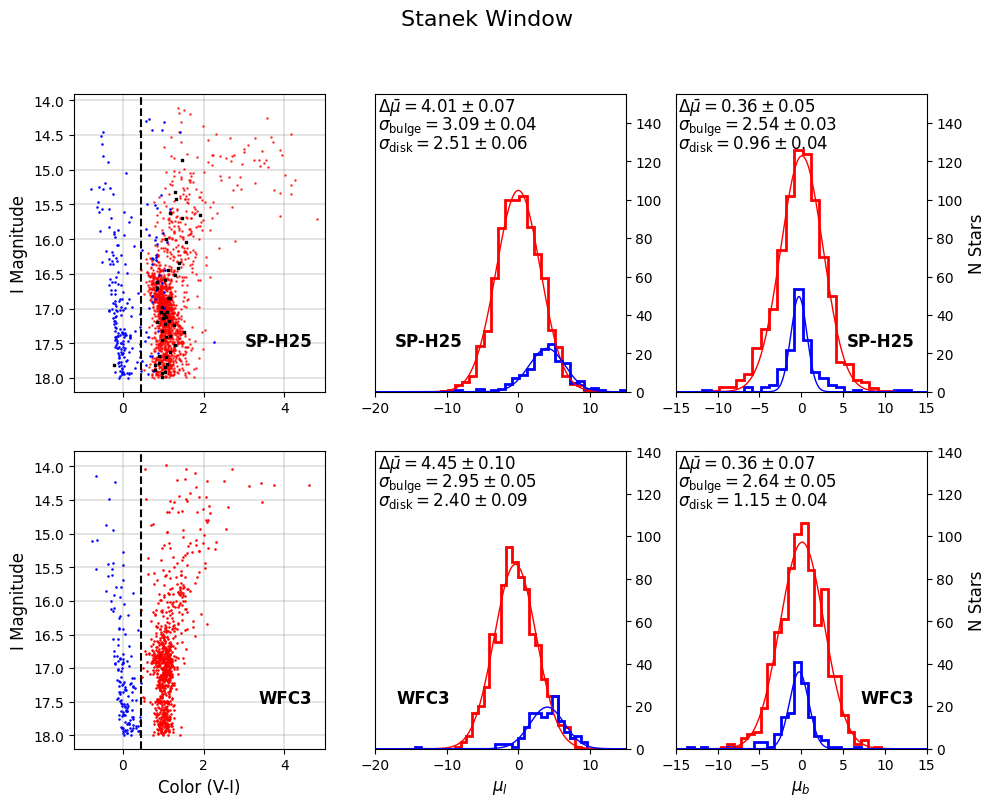

In [19]:
# Plot everything together for the paper
all_fig, all_axs = plt.subplots(2,3, figsize=(11, 8.5))
all_fig.suptitle(window+" Window", fontsize=16)

all_ax1 = all_axs[0, 0]
all_ax2 = all_axs[0, 1]
all_ax3 = all_axs[0, 2]
all_ax4 = all_axs[1, 0]
all_ax5 = all_axs[1, 1]
all_ax6 = all_axs[1, 2]

# Redefine all the dataframes by population cut
bulge_pop_df = df[df['pop'] == bulge_pop]
disk_pop_df = df[(df['pop'].isin(disk_pops)) & (df['Dist'] < galcenter)]
fardisk_pop_df = df[(df['pop'].isin(disk_pops)) & (df['Dist'] > galcenter)]

# Plot cmds
all_ax1.set_axisbelow(True)
all_ax4.set_axisbelow(True)
all_ax1.grid(color='gray', linestyle='-', linewidth=0.3)
all_ax4.grid(color='gray', linestyle='-', linewidth=0.3)
#all_ax1.set_title("SP-H25")
all_ax1.set_ylabel("I Magnitude", fontsize=fontsize)
all_ax4.set_ylabel("I Magnitude", fontsize=fontsize)
#all_ax1.set_xlabel("Color (V-I)", fontsize=fontsize)
#all_ax4.set_title("WFC3")
all_ax4.set_xlabel("Color (V-I)", fontsize=fontsize)

all_ax1.scatter(bulge_pop_df[spfilt2]-bulge_pop_df[spfilt1], bulge_pop_df[spfilt1], s=0.7, label = "Red (Bulge)", alpha = 0.7, color = "red")
all_ax1.scatter(disk_pop_df[spfilt2]-disk_pop_df[spfilt1], disk_pop_df[spfilt1], s=0.7, label = "Blue (Near Disk)", alpha = 1., color = "blue")
all_ax1.scatter(fardisk_pop_df[spfilt2]-fardisk_pop_df[spfilt1], fardisk_pop_df[spfilt1], s=4., label = "Far Disk", color = "black", marker = "s")
all_ax1.axvline(colorcut, color="black", linestyle="--")
all_ax1.set_xlim(-1.2, 5)
#all_ax1.legend()
all_ax1.invert_yaxis()

archive_I = archive_I[archive_I < magcut]
all_ax4.scatter(archive_color[bulge_mask], archive_I[bulge_mask], s=0.7, label = "Red (Bulge)", color = "red")
all_ax4.scatter(archive_color[disk_mask], archive_I[disk_mask], s=0.7, label = "Blue (Disk)", color = "blue")
all_ax4.axvline(arch_colorcut, color="black", linestyle="--")
all_ax4.set_xlim(-1.2, 5)
#all_ax4.legend()
all_ax4.invert_yaxis()

# Plot histograms
all_ax2.set_xlim(-20, 15)	# Set x-axis limits
#all_ax1.invert_xaxis()	# Invert x-axis
all_ax3.set_xlim(-15, 15)
all_ax2.set_ylim(0, 155)
all_ax3.set_ylim(0, 155)

all_ax5.set_xlim(-20, 15)
#all_ax3.invert_xaxis()
all_ax6.set_xlim(-15, 15)
all_ax5.set_ylim(0, 140)
all_ax6.set_ylim(0, 140)

all_ax5.set_xlabel(r'$\mu_l$', fontsize=fontsize)
all_ax6.set_xlabel(r'$\mu_b$', fontsize=fontsize)
all_ax3.set_ylabel("N Stars", fontsize=fontsize)
all_ax6.set_ylabel("N Stars", fontsize=fontsize)
all_ax3.yaxis.set_label_position("right")
all_ax6.yaxis.set_label_position("right")
all_ax2.yaxis.tick_right()
all_ax3.yaxis.tick_right()
all_ax5.yaxis.tick_right()
all_ax6.yaxis.tick_right()

all_ax1.text(0.95, 0.2, "SP-H25", transform=all_ax1.transAxes, ha="right", va="top", fontsize=fontsize, fontweight="bold")
all_ax2.text(0.35, 0.2, "SP-H25", transform=all_ax2.transAxes, ha="right", va="top", fontsize=fontsize, fontweight="bold")
all_ax3.text(0.95, 0.2, "SP-H25", transform=all_ax3.transAxes, ha="right", va="top", fontsize=fontsize, fontweight="bold")
all_ax4.text(0.95, 0.2, "WFC3", transform=all_ax4.transAxes, ha="right", va="top", fontsize=fontsize, fontweight="bold")
all_ax5.text(0.30, 0.2, "WFC3", transform=all_ax5.transAxes, ha="right", va="top", fontsize=fontsize, fontweight="bold")
all_ax6.text(0.95, 0.2, "WFC3", transform=all_ax6.transAxes, ha="right", va="top", fontsize=fontsize, fontweight="bold")

subplot(all_ax2, data_dict_l, bin_edges, 0, True, hubble_sp_norm_factor_lbulge, hubble_sp_norm_factor_ldisk)
subplot(all_ax3, data_dict_b, bin_edges, 0, True, hubble_sp_norm_factor_bbulge, hubble_sp_norm_factor_bdisk)
subplot(all_ax5, arch_dict_l, arch_bin_edges, 1)
subplot(all_ax6, arch_dict_b, arch_bin_edges, 1)
plt.savefig(window+"_propermotions.pdf", format="pdf")
plt.show()

In [20]:
################ Total Distribution Plotting ################
if norm == "False":
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(10, 5))
    fig2.suptitle("Total Proper Motion Distribution "+window+"_Huston2025")
    
    ax3.set_xlabel(r'$\mu_l$')
    ax3.set_ylabel('stars / arcmin$^2$ / mag') 
    ax3.set_xlim(-20, 10)	# Set x-axis limits
    ax3.invert_xaxis()	# Invert x-axis
    #ax3.stairs((hist_bulge_mul+hist_disk_mul+hist_fardisk_mul), edges_bulge_mul)
    ax3.stairs((hist_bl+hist_dl+hist_fardisk_mul), edges_bl)
    
    ax4.set_xlabel(r'$\mu_b$')
    ax4.set_xlim(-15, 15)
    #ax4.stairs((hist_bulge_mub+hist_disk_mub+hist_fardisk_mub), edges_bulge_mub)
    ax4.stairs((hist_bb+hist_db+hist_fardisk_mub), edges_bb)
    
    fig2.savefig("total_pm_distribution_"+window+"_Huston2025.png")
    plt.show()

print("\n(std, mean) calculated with numpy")
print("Bulge mul: ("+str(np.std(bulge_mul))+", "+str(np.mean(bulge_mul))+")")
print("Disk mul: ("+str(np.std(disk_mul))+", "+str(np.mean(disk_mul))+")")
print("Bulge mub: ("+str(np.std(bulge_mub))+", "+str(np.mean(bulge_mub))+")")
print("Disk mub: ("+str(np.std(disk_mub))+", "+str(np.mean(disk_mub))+")")


(std, mean) calculated with numpy
Bulge mul: (3.0548328214027873, 0.07202825831117939)
Disk mul: (3.5458500421555192, 3.698395421936938)
Bulge mub: (2.8525674831503602, -0.061030827450121526)
Disk mub: (2.319242330734081, -0.1622858859702703)
